# Subsystem integration cross-check

本 notebook 展示已保存的实验资产。报告位于 `playground/subsystem/subsystem_crosscheck/results/2026-09-06/REPORT.md`。

Bacon–Shor：匹配 publication 的 capacity 检查 + native SE circuit noise。
SHYPS：reference / regenerated / generic 分开比较。更多 detectors 不保证 BPOSD 更好。
全部纵轴默认是 **logical block failure per shot**，不自动除以 rounds 或 logical 数。

正式 Bacon–Shor demo 见 `notebooks/Memory/memory_bacon_shor.ipynb`；SHYPS visualization 见 `notebooks/Memory/memory_subsystem.ipynb`。


In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import display, Image, Markdown

root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "lightstim").is_dir())
assets = root / "playground/subsystem/subsystem_crosscheck/results/2026-09-06"
rates = pd.read_csv(assets / "results.csv")
paper_comparison = pd.read_csv(assets / "comparison_to_paper.csv")
display(Markdown(f"已保存 {len(rates)} 个聚合点。完整方法、失败案例和限制见 REPORT.md。"))


已保存 117 个聚合点。完整方法、失败案例和限制见 REPORT.md。

## Bacon–Shor: exact noise-model comparison

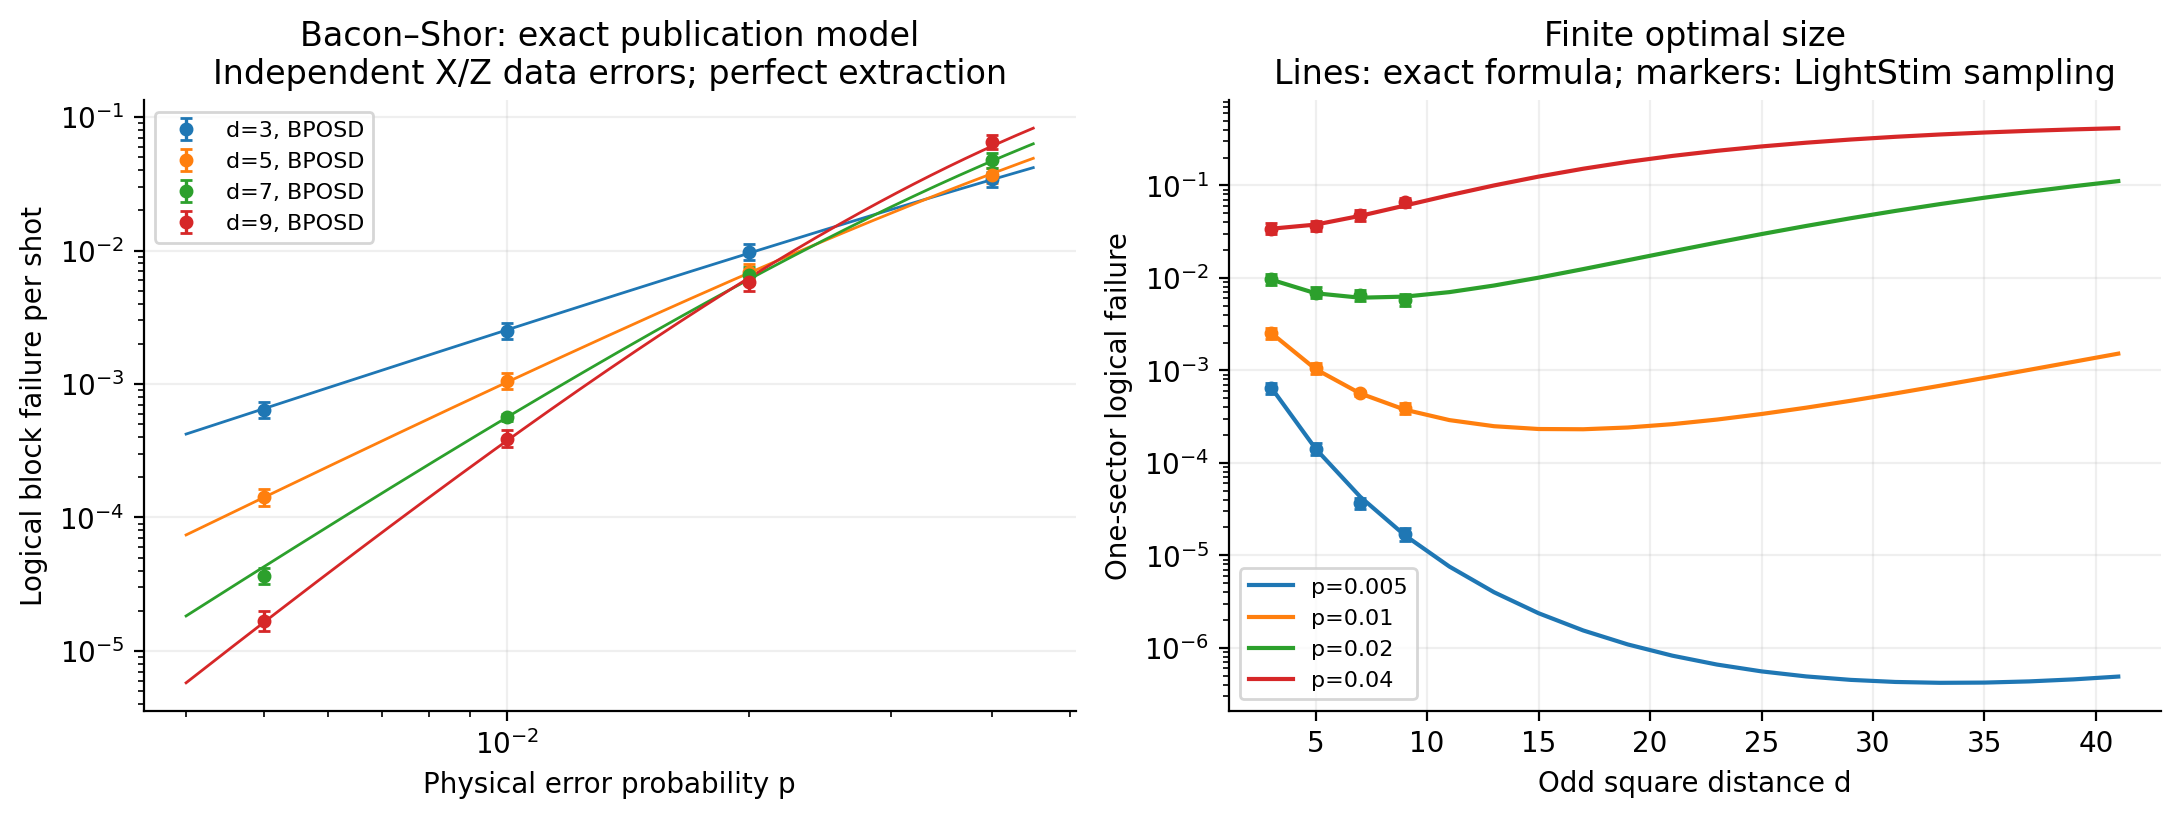

In [2]:
display(Image(filename=str(assets / "figures/bacon_capacity.png")))

## Bacon–Shor: native circuit and decoders

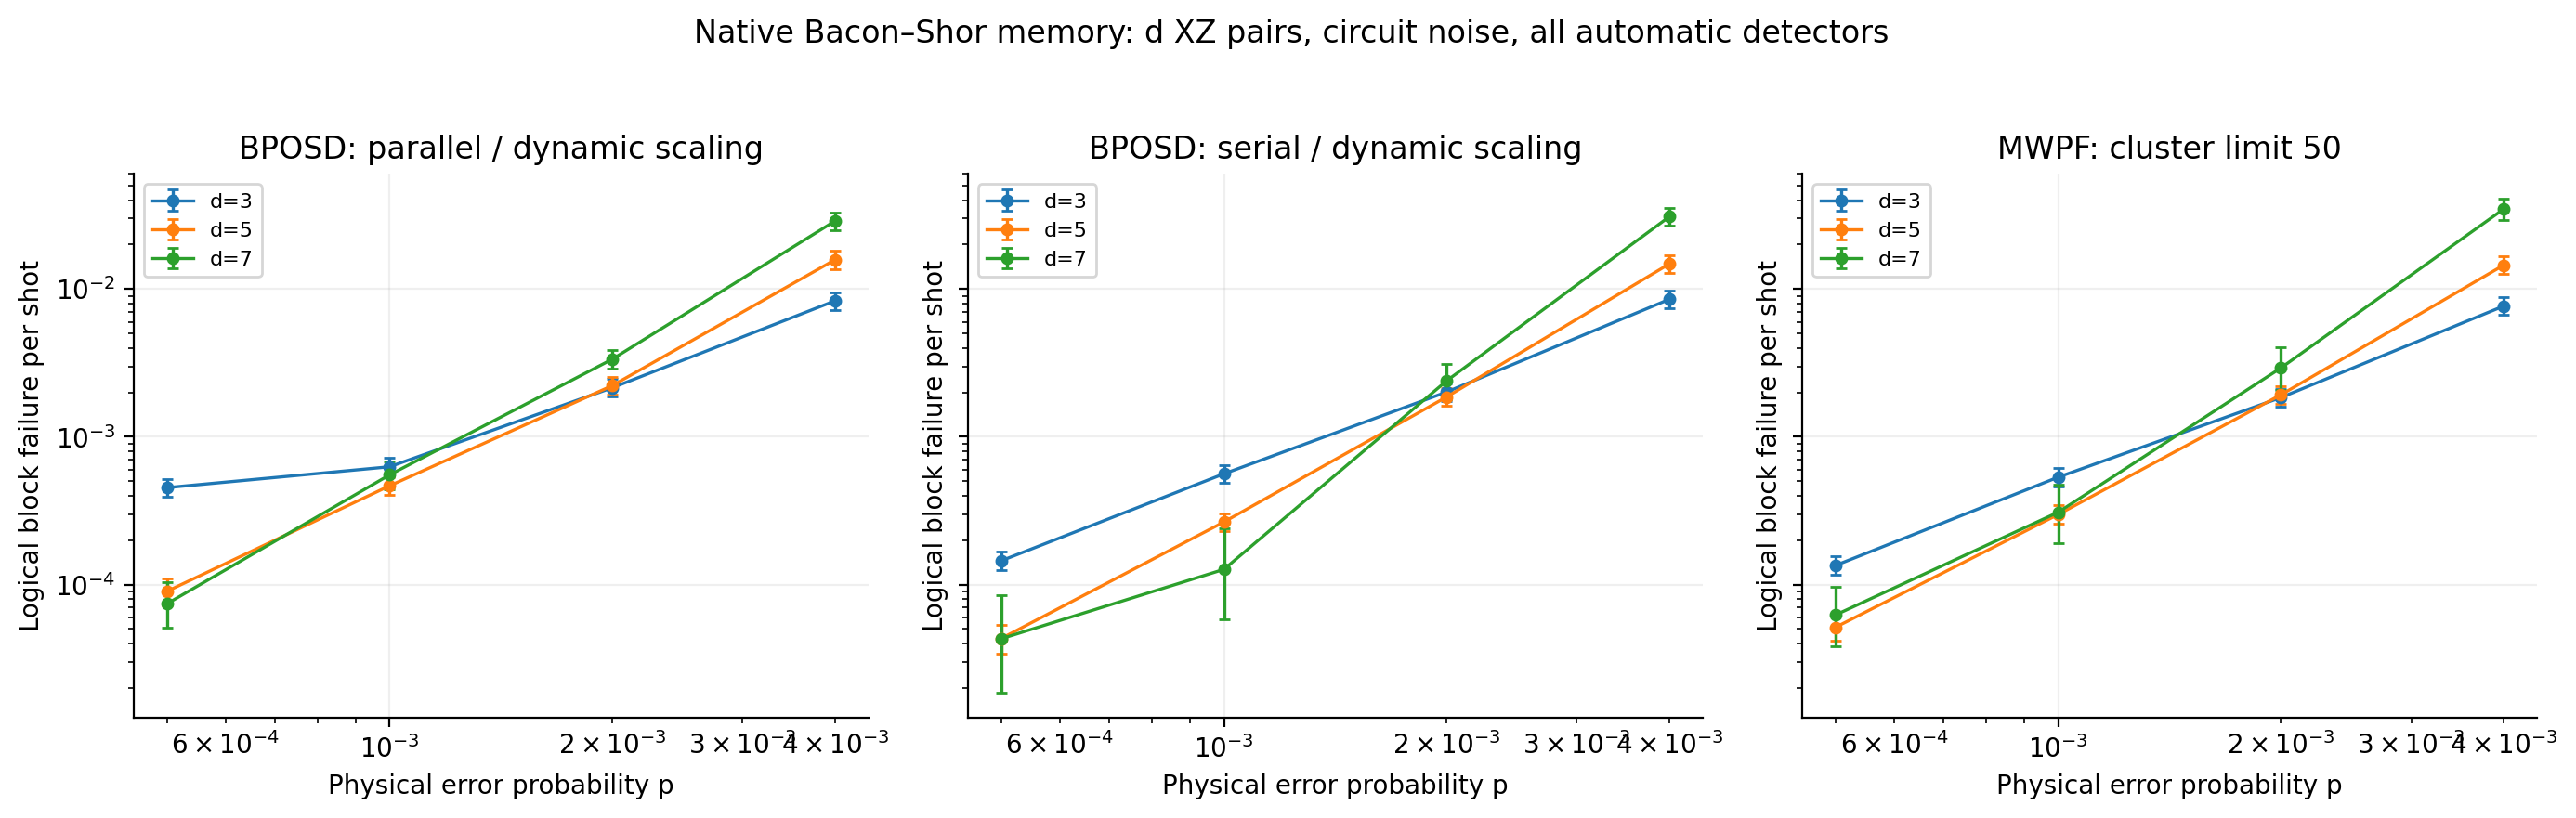

In [3]:
display(Image(filename=str(assets / "figures/bacon_circuit_decoders.png")))

## SHYPS: detector subspaces

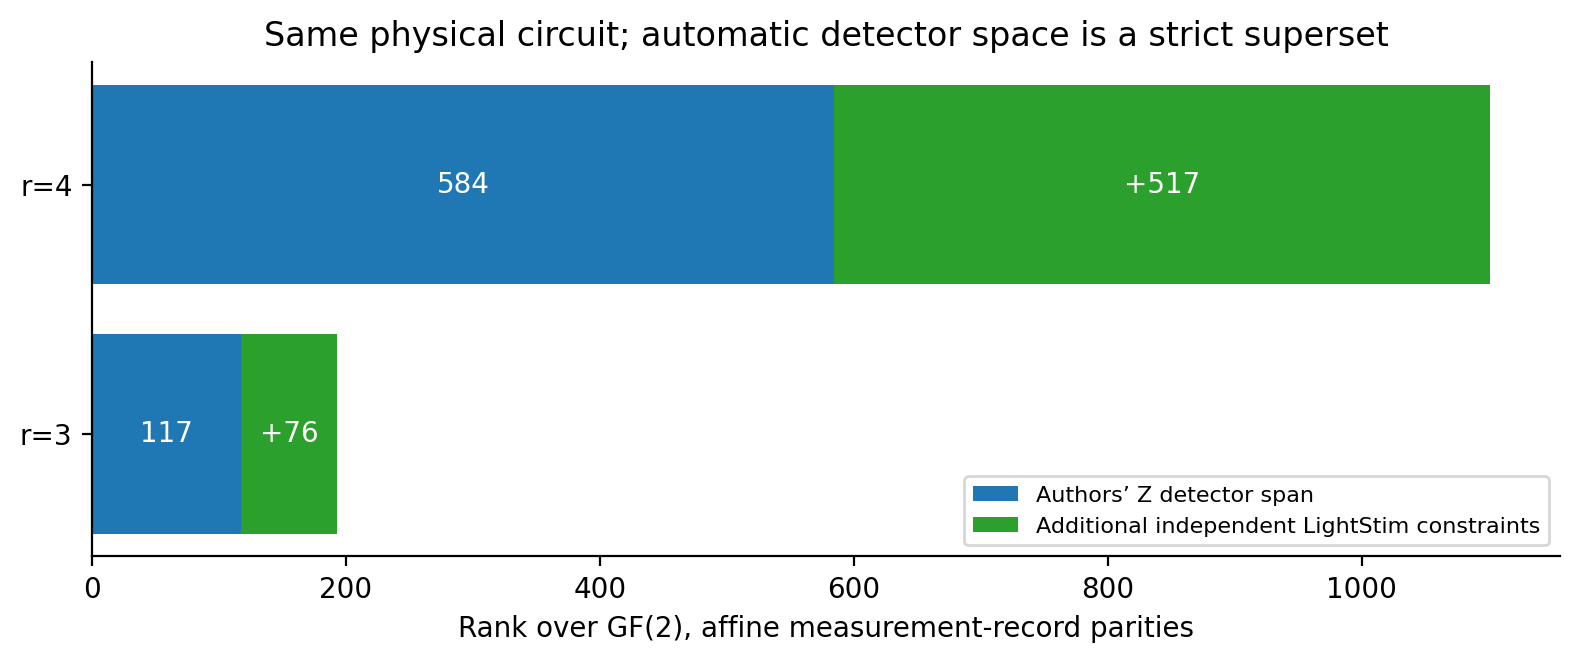

In [4]:
display(Image(filename=str(assets / "figures/shyps_detector_spaces.png")))

## SHYPS: authors’ exact circuit / different decoders

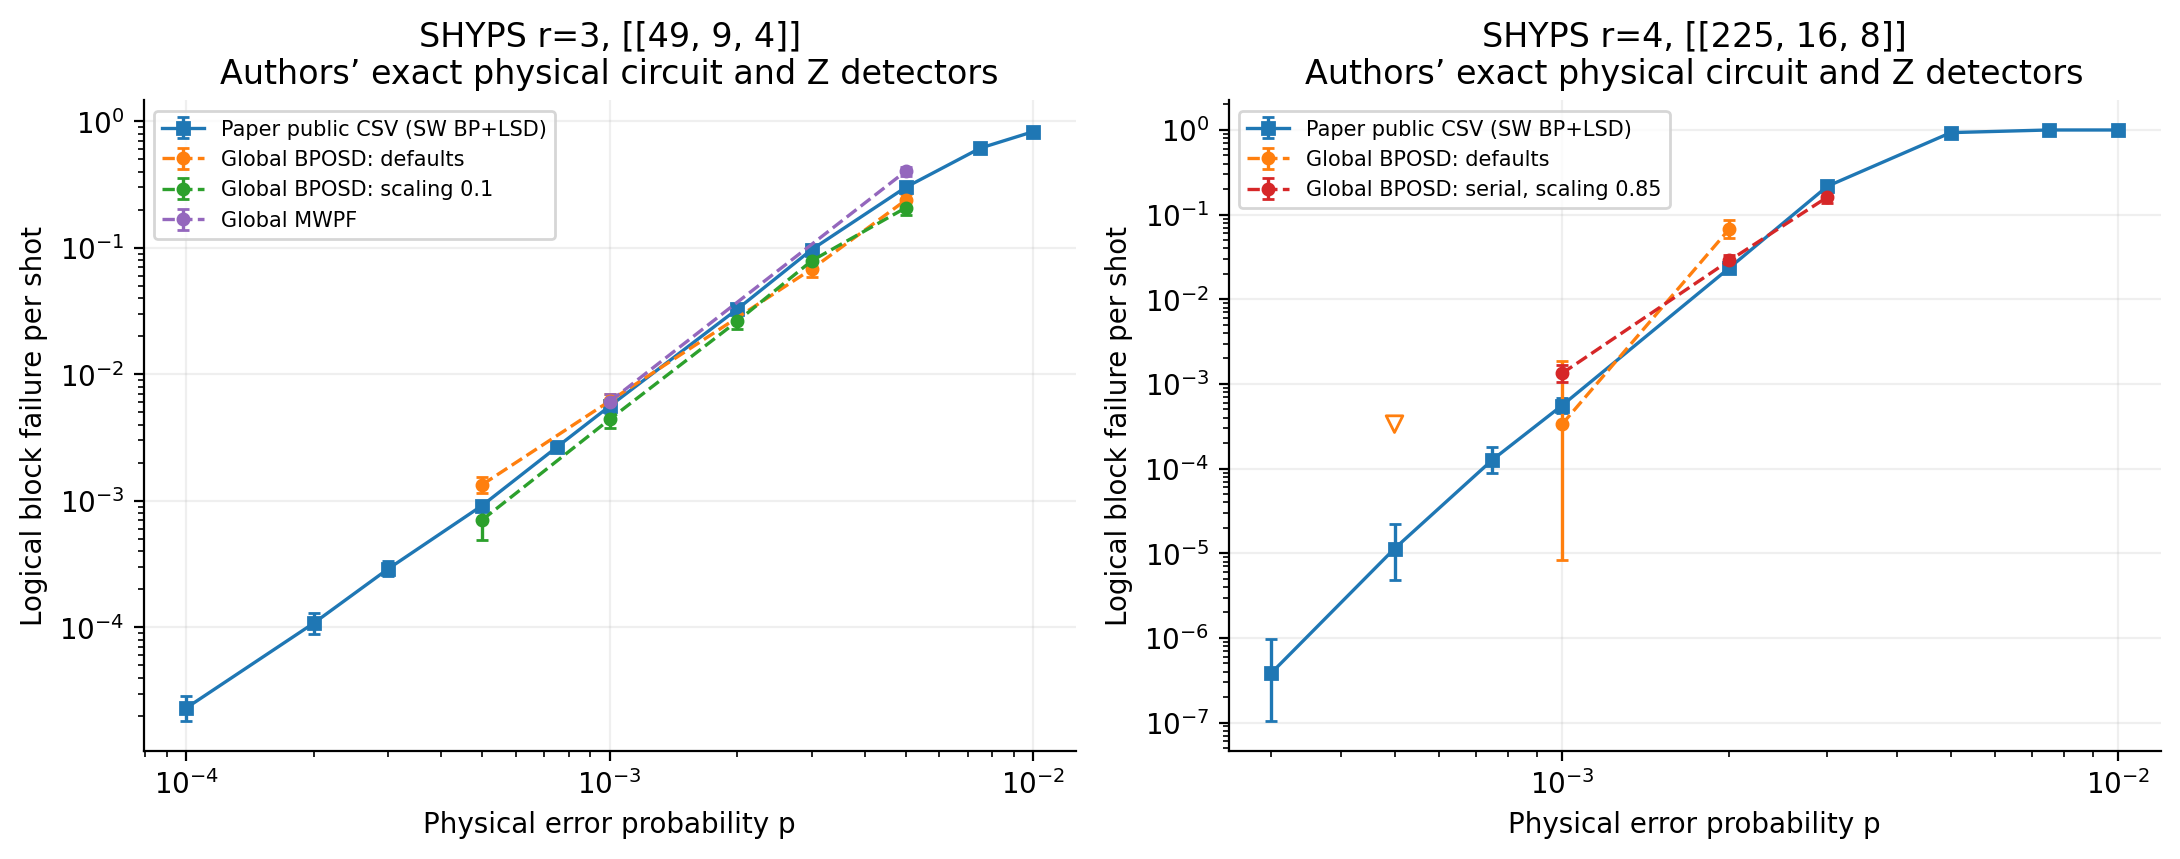

In [5]:
display(Image(filename=str(assets / "figures/shyps_reference_decoders.png")))

## SHYPS: LightStim integration / decoder sensitivity

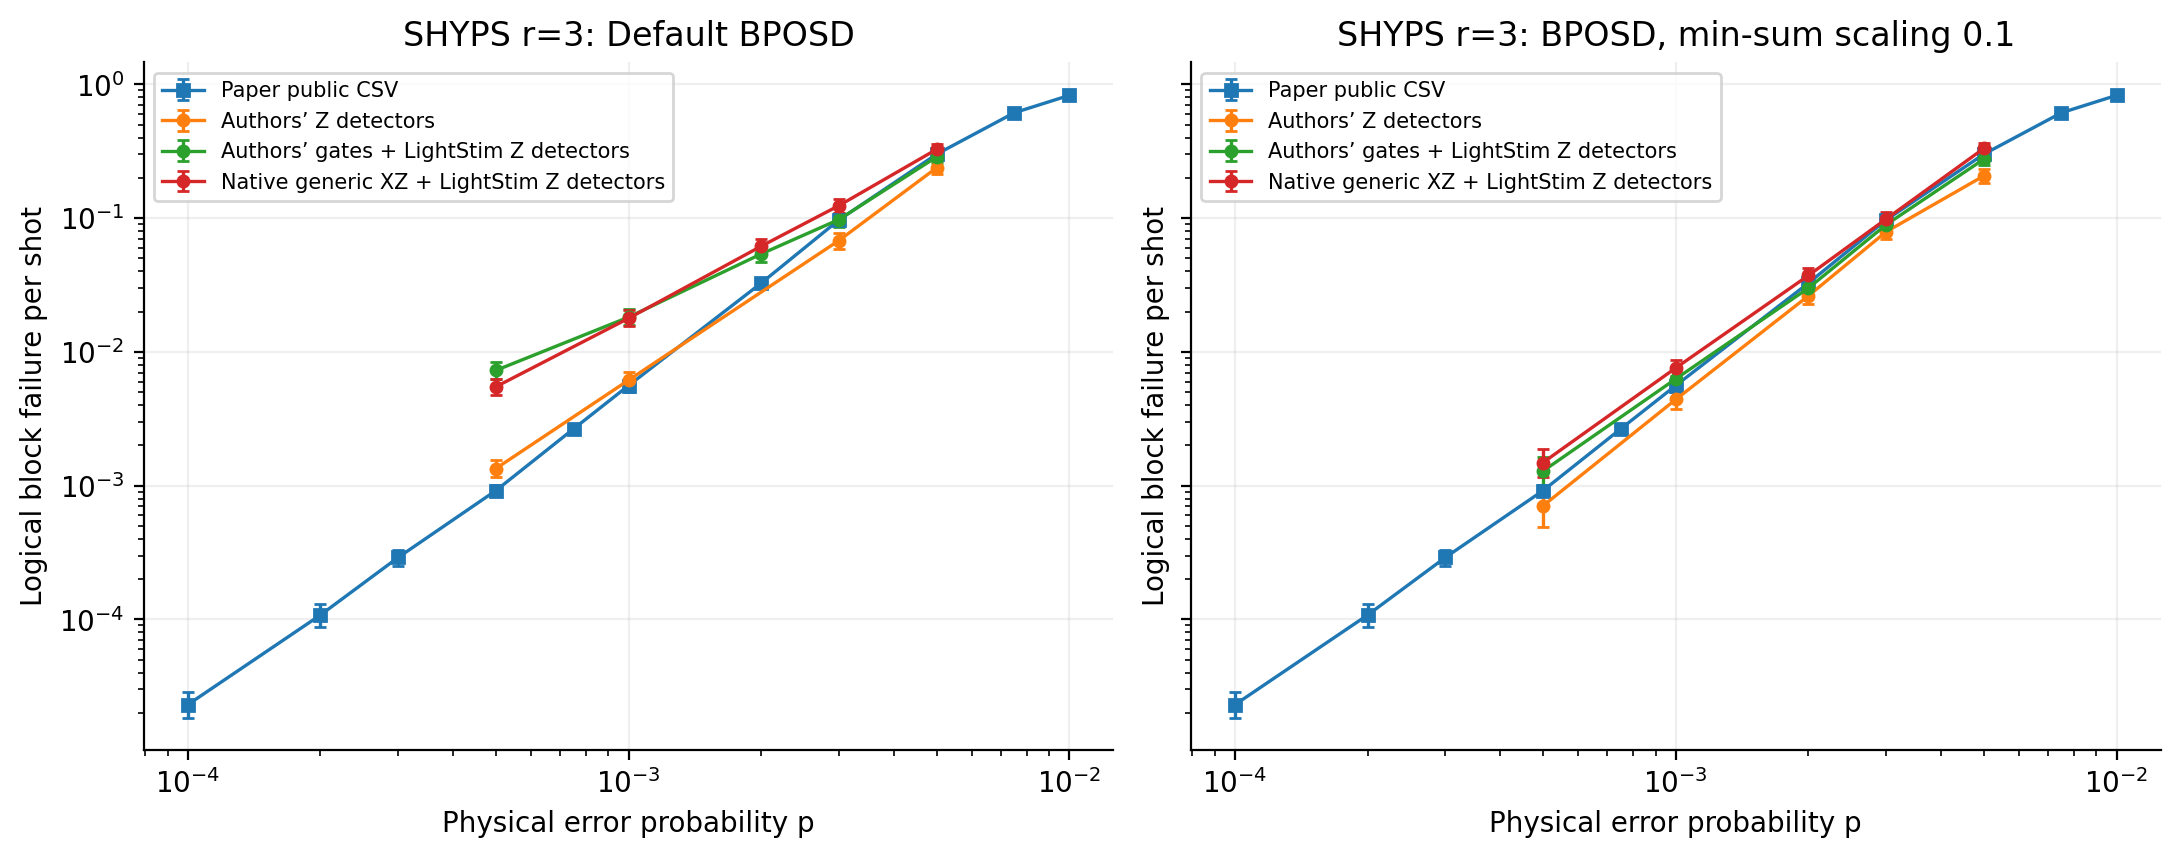

In [6]:
display(Image(filename=str(assets / "figures/shyps_integration_comparison.png")))

## SHYPS r=4: unresolved detector / decoder performance

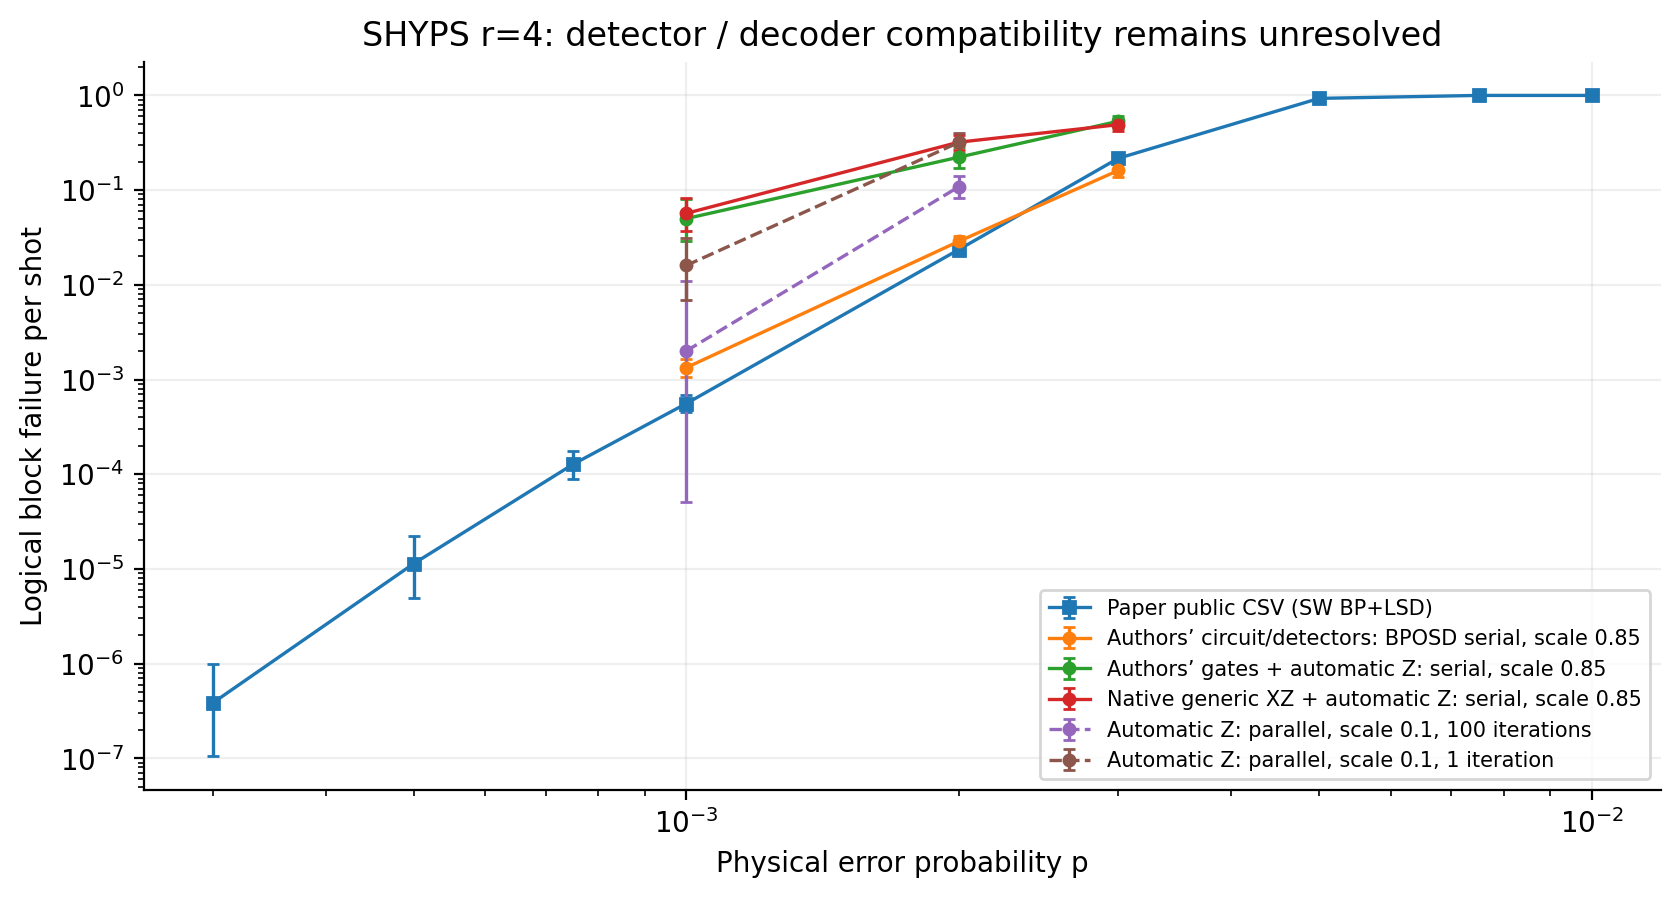

In [7]:
display(Image(filename=str(assets / "figures/shyps_r4_integration.png")))

## 原始计数、置信区间与失败状态

In [8]:
columns = ["experiment", "size", "p", "decoder", "variant", "errors", "shots",
           "ler", "ci95_low", "ci95_high", "decode_failures", "statuses"]
display(rates[columns])

,experiment,size,p,decoder,variant,errors,shots,ler,ci95_low,ci95_high,decode_failures,statuses
0,bacon_capacity,3,0.005,bposd,default,200,314000,0.000637,0.000552,0.000732,0,error_target
1,bacon_capacity,3,0.010,bposd,default,201,80000,0.002512,0.002177,0.002884,0,error_target
2,bacon_capacity,3,0.020,bposd,default,204,21000,0.009714,0.008432,0.011135,0,error_target
3,bacon_capacity,3,0.040,bposd,default,205,6000,0.034167,0.029715,0.039079,0,error_target
4,bacon_capacity,5,0.005,bposd,default,200,1414000,0.000141,0.000123,0.000162,0,error_target
...,...,...,...,...,...,...,...,...,...,...,...,...
112,shyps_reference_z,4,0.003,bposd,serial85,137,850,0.161176,0.137078,0.187650,0,error_target
113,shyps_reference_z,3,0.001,mle-ilp,default,183,5000,0.036600,0.031567,0.042183,171,shot_cap
114,shyps_reference_z,3,0.005,mle-ilp,default,267,400,0.667500,0.618971,0.713529,258,error_target
115,shyps_reference_z,3,0.001,mwpf,default,189,31000,0.006097,0.005261,0.007027,0,time_cap


## 与公开 CSV 的对照（p=0.001）

In [9]:
display(paper_comparison.loc[paper_comparison.p == 0.001,
    ["experiment", "size", "decoder", "variant", "errors", "shots", "ler",
     "paper_errors", "paper_shots", "paper_ler", "ratio_to_paper", "decode_failures"]])

,experiment,size,decoder,variant,errors,shots,ler,paper_errors,paper_shots,paper_ler,ratio_to_paper,decode_failures
0,shyps_auto_xz,3,bposd,default,75,7000,0.010714,291,51938,0.005603,1.912297,0
3,shyps_auto_z,3,bposd,default,209,11500,0.018174,291,51938,0.005603,3.243700,0
8,shyps_auto_z,3,bposd,scale01,201,32000,0.006281,291,51938,0.005603,1.121084,0
12,shyps_auto_z,4,bposd,scale01_iter1,8,500,0.016000,97,174245,0.000557,28.741443,0
14,shyps_auto_z,4,bposd,scale01_iter100,1,500,0.002000,97,174245,0.000557,3.592680,0
16,shyps_auto_z,4,bposd,serial85,16,320,0.050000,97,174245,0.000557,89.817010,0
19,shyps_auto_z,3,mwpf,default,204,6300,0.032381,291,51938,0.005603,5.779388,0
21,shyps_generic_xz,3,bposd,default,68,6500,0.010462,291,51938,0.005603,1.867187,0
24,shyps_generic_z,3,bposd,default,205,11500,0.017826,291,51938,0.005603,3.181620,0
29,shyps_generic_z,3,bposd,scale01,201,26500,0.007585,291,51938,0.005603,1.353762,0
